In [1]:
from datasets import load_dataset
import tiktoken
import torch
import humanize
import torch.nn as nn
from torch.optim import Adam
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import clear_output
from IPython import display
from pathlib import Path

def ensure_file(file_path):
  base_path = Path(file_path).parent
  Path(base_path).mkdir(parents=True, exist_ok=True)
  return file_path

def get_line_stats(batch, tokenizer):
  tokens_batch = []
  length_batch = []
  for row in batch["text"]:
    tokens = tokenizer.encode(row, allowed_special={"<|endoftext|>"})
    tokens_batch.append(tokens)
    length_batch.append(len(tokens))
  return {"tokens": tokens_batch, "length": length_batch}

def prepare_dataset(name, cache_file, tokenizer, pad_token, seq_len):
  # Load the dataset and gather token lengths
  dataset = load_dataset(name, split="train")
  dataset = dataset.map(
    lambda b: get_line_stats(b, tokenizer),
    batched=True,
    remove_columns=["text"]
  )

  # Pad each token sequence into a fixed size
  max_len = max(dataset["length"]) + 1
  nearest_multiple = ((max_len // seq_len) + 1) * seq_len
  shape = (len(dataset), nearest_multiple)
  padded = torch.full(shape, pad_token, dtype=torch.int)
  for i, tokens in enumerate(dataset["tokens"]):
    padded[i, :len(tokens)] = torch.tensor(tokens, dtype=torch.int)

  # Split each sequence into chunks and cache them
  num_chunks = padded.shape[1] // seq_len
  chunks = torch.chunk(padded, chunks=num_chunks, dim=1)
  torch.save(chunks, cache_file)
  return len(dataset), chunks

In [2]:
def init_weights(module):
  if isinstance(module, nn.Linear):
    nn.init.kaiming_normal_(module.weight)
    if module.bias is not None:
      nn.init.constant_(module.bias, 0.0)

paramtensor = lambda *args: nn.Parameter(torch.randn(*args))

class Decoder(nn.Module):
  # B x T x E input and output, where B is the batch size, T is the token
  # sequence length and E is the embedding dimension.
  def __init__(self, E, H, D_k, D_f):
    super().__init__()
    self.H, self.D_k = H, D_k
    self.D_k_scale = 1 / torch.sqrt(torch.tensor(self.D_k)).item()

    # Linear projection matrices for the query, key and value
    # B x T x E -> B x H x T x D_k, where H is the number of attention heads and
    # D_k is the query, key and value embedding dimension for each attention head
    self.Q_proj = paramtensor(E, D_k * H)
    self.K_proj = paramtensor(E, D_k * H)
    self.V_proj = paramtensor(E, D_k * H)
    # Output projection for the scaled values of the concatenated attention heads
    self.O_proj = paramtensor(D_k * H, E)

    self.norm1 = nn.LayerNorm(E) # After the multihead self-attention
    self.norm2 = nn.LayerNorm(E) # After the feed forward network

    # Feed forward network: B x T x E -> B x T x D_f -> B x T x E,
    # where D_f is the dimension of the hidden layer
    self.ffn = nn.Sequential(nn.Linear(E, D_f), nn.ReLU(), nn.Linear(D_f, E))

  def forward(self, x, M):
    # Linearly project queries, keys and value for each attention head, perform
    # multi-head masked self-attention on the input, each concatenate each attention
    # head's values and linearly project them back into embedding space.
    B, T = x.shape[0], x.shape[1]
    Q = (x @ self.Q_proj).reshape(B, T, self.H, self.D_k).transpose(1, 2)
    K = (x @ self.K_proj).reshape(B, T, self.H, self.D_k).transpose(1, 2)
    V = (x @ self.V_proj).reshape(B, T, self.H, self.D_k).transpose(1, 2)

    # The causal mask ensures that future tokens can't be attended to since e^-inf approaches 0.
    scaled = F.scaled_dot_product_attention(Q, K, V, attn_mask=M)
    # Concatenate each attention head and linearly project the result back into embedding space
    attended = scaled.transpose(1, 2).reshape(B, T, self.H * self.D_k) @ self.O_proj

    # Process the attended values
    x = self.norm1(attended + x)
    ffn_output = self.ffn(x)
    return self.norm2(ffn_output + x)

class Transformer(nn.Module):
  # B x T input and B x T x V output, where B is the batch size, T is the token
  # sequence length. Each token is an index into the vocabulary (V).
  def __init__(self, V, E, T, H, D_k, D_f, L, device):
    super().__init__()
    # Embeddings: B x T -> B x T x E, where E is the embedding dimension
    self.tok_embed = paramtensor(V, E)
    self.pos_embed = paramtensor(T, E)
    self.E_scale = torch.sqrt(torch.tensor(E)).item()

    # Share the same causal mask for all decoders to save memory
    temp = torch.full((T, T), float("-inf"), device=device)
    self.causal_mask = torch.triu(temp, diagonal=1).to(device)

    # Transformer decoder layers are referred to as decoders because of their
    # auto-regressive masked self-attention, not because of their structure.
    self.layers = nn.ModuleList([Decoder(E, H, D_k, D_f) for _ in range(L)])

  def forward(self, x):
    # Each token selects a row from the learned token embedding matrix.
    embeddings = self.tok_embed[x] * self.E_scale + self.pos_embed
    for layer in self.layers:
      embeddings = layer(embeddings, self.causal_mask)

    # Convert embeddings back into tokens by creating a B x T x V logit matrix. During
    # training, the difference between the actual next token and the most probable next
    # token will be minimized. During inference, the next most probable token will be selected.
    return embeddings @ self.tok_embed.T

In [3]:
dataset_name = "BabyLM-community/BabyLM-2026-Strict-Small"
data_cache_file = ensure_file(".cache/prepared-dataset.pth")
model_cache_file = ensure_file(".cache/model-weights.pth")
hyperparams = {
  "embedding_dim": 512, "num_attn_heads": 12, "attn_dim": 64,
  "ffn_dim": 2048, "seq_len": 512, "num_layers": 12,
  "batch_size": 16, "epochs": 10, "train_split": 0.25
}
experiment_name = "Overfit test"

# EOS token = Pad token to minimize the vocab size
tokenizer = tiktoken.encoding_for_model("gpt2")
eos_token = tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"})[0]

device = "cuda" if torch.cuda.is_available() else "cpu"
model = Transformer(
  tokenizer.n_vocab,
  hyperparams["embedding_dim"],
  hyperparams["seq_len"],
  hyperparams["num_attn_heads"],
  hyperparams["attn_dim"],
  hyperparams["ffn_dim"],
  hyperparams["num_layers"],
  device
).to(device)
model.apply(init_weights)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Using {device} to run a {humanize.intword(num_params)} parameter model")

try:
  chunks = torch.load(data_cache_file)
  total_rows = chunks[0].shape[0]
except:
  total_rows, chunks = prepare_dataset(dataset_name, data_cache_file,
                           tokenizer, eos_token, hyperparams["seq_len"])
num_train_rows = int(total_rows * hyperparams["train_split"])

Using cuda to run a 70.1 million parameter model


README.md: 0.00B [00:00, ?B/s]

bnc_spoken.train.txt: 0.00B [00:00, ?B/s]

childes.train.txt:   0%|          | 0.00/15.2M [00:00<?, ?B/s]

gutenberg.train.txt:   0%|          | 0.00/14.0M [00:00<?, ?B/s]

open_subtitles.train.txt:   0%|          | 0.00/12.2M [00:00<?, ?B/s]

simple_wiki.train.txt: 0.00B [00:00, ?B/s]

switchboard.train.txt: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/1104106 [00:00<?, ? examples/s]

Map:   0%|          | 0/1104106 [00:00<?, ? examples/s]

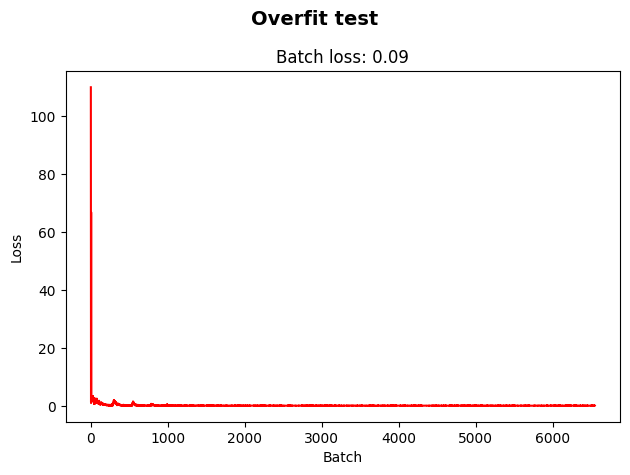

In [4]:
# Train the model
model.train()
torch.enable_grad()

optimizer = Adam(model.parameters(), betas=(0.9, 0.98), eps=1e-9)
criterion = nn.CrossEntropyLoss()

fig, ax = plt.subplots()
train_losses = []

for _ in range(hyperparams["epochs"]):
  shuffled = torch.randperm(num_train_rows)

  for i in range(0, num_train_rows, hyperparams["batch_size"]):
    indices = shuffled[i: i + hyperparams["batch_size"]]
    batch_losses = []

    for j in range(len(chunks)):
      # The correct next token is the sequence shifted to the left
      rows = chunks[j][indices].to(device)
      target = torch.full(rows.shape, eos_token, dtype=torch.long, device=device)
      target[:, :-1] = rows[:, 1:]

      with torch.autocast(device_type=device, dtype=torch.bfloat16):
        prediction = model(rows)
        # Flatten tensors to make CrossEntropyLoss work well:
        # prediction: B x T x V -> B * T x V, target: B x T -> 1 x B * T
        loss = criterion(
          prediction.reshape(-1, prediction.shape[-1]),
          target.reshape(-1)
        )

      batch_losses.append(loss.item())
      (loss / len(chunks)).backward() # Average the loss across chunks

    # Average gradients across different chunks of the same sequence
    optimizer.step()
    optimizer.zero_grad(set_to_none=True)

    # Plot a loss curve in real time
    mean_loss = sum(batch_losses) / len(batch_losses)
    train_losses.append(mean_loss)

    clear_output(wait=True)
    ax.clear()
    ax.plot(train_losses, "r-")
    ax.autoscale_view(scalex=True, scaley=True)
    fig.suptitle(experiment_name, fontsize=14, fontweight="bold")
    ax.set_title(f"Batch loss: {mean_loss:.2f}")
    ax.set_xlabel("Batch")
    ax.set_ylabel("Loss")

    fig.tight_layout() # Prevents overlapping labels
    display.display(fig)

torch.save(model.state_dict(), model_cache_file)
fig.savefig(f"{experiment_name}.png", dpi=300, bbox_inches="tight")

In [ ]:
model.eval()
torch.set_grad_enabled(False)

# Compute the mean test loss
test_losses = []
for i in range(num_train_rows, total_rows, hyperparams["batch_size"]):
  if total_rows - i < hyperparams["batch_size"]:
    break
  batch_losses = []

  for j in range(len(chunks)):
    rows = chunks[j][i: i + hyperparams["batch_size"]].to(device)
    target = torch.full(rows.shape, eos_token, dtype=torch.long, device=device)
    target[:, :-1] = rows[:, 1:]

    with torch.autocast(device_type=device, dtype=torch.bfloat16):
      prediction = model(rows)
      loss = criterion(
        prediction.reshape(-1, prediction.shape[-1]),
        target.reshape(-1)
      )

    batch_losses.append(loss.item())

  test_losses.append(sum(batch_losses) / len(batch_losses))

print("Mean test loss:", sum(test_losses) / len(test_losses))
torch.set_grad_enabled(True)

#row = torch.randint(low=num_train_rows, high=total_rows, size=(1,))
#sequence = chunks[0][row].to(device)
#next_tokens = torch.argmax(model(sequence), dim=-1)
#print("Input sequence:", tokenizer.decode(sequence.tolist()[0]))
#print("Predicted sequence:", tokenizer.decode(next_tokens.tolist()[0]))